Khai báo thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, DateFormatter, YearLocator
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.layers import Dense, InputLayer, LSTM
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model

Đọc và mô tả dữ liệu


In [31]:
df=pd.read_csv('Hanoi_weather.csv')
df.head(100)

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,Hanoi,2015-10-01,34.1,24.0,29.6,39.7,24.0,34.3,24.1,73.8,...,18.4,8,NaN,2015-10-01T05:47:26,2015-10-01T17:45:12,0.60,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain,"48820099999,48823099999,48825099999,4883109999..."
1,Hanoi,2015-10-02,32.1,24.5,27.6,36.6,24.5,30.2,23.6,79.9,...,12.9,7,NaN,2015-10-02T05:47:42,2015-10-02T17:44:17,0.64,"Rain, Partially cloudy",Partly cloudy throughout the day with rain.,rain,"48820099999,48823099999,48825099999,4883109999..."
2,Hanoi,2015-10-03,32.1,25.7,28.6,37.5,25.7,31.6,23.8,76.7,...,13.7,7,NaN,2015-10-03T05:47:59,2015-10-03T17:43:22,0.67,"Rain, Partially cloudy",Partly cloudy throughout the day with afternoo...,rain,"48820099999,48823099999,48825099999,4883109999..."
3,Hanoi,2015-10-04,32.0,25.5,28.9,35.8,25.5,31.2,22.1,68.2,...,16.9,8,NaN,2015-10-04T05:48:16,2015-10-04T17:42:27,0.70,"Rain, Partially cloudy",Partly cloudy throughout the day with afternoo...,rain,"48820099999,48823099999,48825099999,4883109999..."
4,Hanoi,2015-10-05,31.2,24.0,27.4,36.1,24.0,28.8,20.9,68.1,...,10.5,6,NaN,2015-10-05T05:48:33,2015-10-05T17:41:33,0.75,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"48820099999,48823099999,48825099999,4883109999..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Hanoi,2016-01-04,25.0,18.0,21.1,25.0,18.0,21.1,18.0,83.1,...,7.0,4,NaN,2016-01-04T06:34:23,2016-01-04T17:28:02,0.81,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,"48820099999,48823099999,48825099999,4883109999..."
96,Hanoi,2016-01-05,26.0,19.0,21.8,26.0,19.0,21.8,19.1,85.4,...,12.4,5,NaN,2016-01-05T06:34:39,2016-01-05T17:28:41,0.84,"Rain, Partially cloudy",Partly cloudy throughout the day with morning ...,rain,"48820099999,48823099999,48825099999,4883109999..."
97,Hanoi,2016-01-06,26.0,20.0,22.4,26.0,20.0,22.4,19.5,85.1,...,7.5,3,NaN,2016-01-06T06:34:54,2016-01-06T17:29:20,0.88,"Rain, Partially cloudy",Partly cloudy throughout the day with rain in ...,rain,"48820099999,48823099999,48825099999,4883109999..."
98,Hanoi,2016-01-07,25.0,20.0,21.7,25.0,20.0,21.7,18.9,84.7,...,5.7,3,NaN,2016-01-07T06:35:08,2016-01-07T17:29:59,0.91,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,"48820099999,48823099999,48825099999,4883109999..."


*   Name: Tên địa điểm
*   datetime: Thời gian
*   tempmax: Nhiệt độ cao nhất trong ngày
*   tempmin: Nhiệt độ thấp nhất trong ngày
*   temp: Nhiệt độ trung bình trong ngày
*   feelslikemax: Nhiệt độ cảm nhận cao nhất
*   feelslikemin: Nhiệt độ cảm nhận thấp nhất
*   feelslike: Nhiệt độ cảm nhận thực tế
*   dew: Điểm sương
*   humidity: Độ ẩm tương đối(%)
*   solarenergy: năng lượng mặt trời tích lũy
*   uvindex: Chỉ số tia cực tím(UV)
*   severerisk: Chỉ số nguy cơ thời tiết khắc nghiệt
*   sunrise:  Thời gian mặt trời mọc
*   sunset: Thời gian mặt trời lặn
*   moonphase: Tỉ lệ phần được chiếu sáng của mặt trăng(Pha mặt trăng)
*   conditions: Điều kiện thời tiết
*   description: Mô tả chi tiết tình trạng thời tiết trong ngày
*   icon: Tên biểu tượng đại diện cho thời tiết
*   stations: Các trạm quan trắc thu thập dữ liệu

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              3654 non-null   object 
 1   datetime          3654 non-null   object 
 2   tempmax           3654 non-null   float64
 3   tempmin           3654 non-null   float64
 4   temp              3654 non-null   float64
 5   feelslikemax      3654 non-null   float64
 6   feelslikemin      3654 non-null   float64
 7   feelslike         3654 non-null   float64
 8   dew               3654 non-null   float64
 9   humidity          3654 non-null   float64
 10  precip            3654 non-null   float64
 11  precipprob        3654 non-null   int64  
 12  precipcover       3654 non-null   float64
 13  preciptype        2667 non-null   object 
 14  snow              3654 non-null   int64  
 15  snowdepth         3654 non-null   int64  
 16  windgust          3654 non-null   float64


In [4]:
# 1. Thống kê mô tả chi tiết các cột dữ liệu (số lượng, trung bình, độ lệch chuẩn, min, max...)
print("--- Thống kê mô tả (Descriptive Statistics) ---")
print(df.describe())

# 2. Kiểm tra dữ liệu bị thiếu (Missing Values)
print("\n--- Kiểm tra dữ liệu bị thiếu (Null Values) ---")
missing_values = df.isna().sum()
print(missing_values)

# Nếu muốn xem kỹ hơn có bao nhiêu dòng bị trùng lặp (nếu cần)
print("\n--- Số lượng dòng bị trùng lặp ---")
print(f"Duplicate rows: {df.duplicated().sum()}")

--- Thống kê mô tả (Descriptive Statistics) ---
           tempmax      tempmin         temp  feelslikemax  feelslikemin  \
count  3654.000000  3654.000000  3654.000000   3654.000000   3654.000000   
mean     28.450246    21.873344    24.834537     32.522961     22.622167   
std       5.811126     4.856627     5.110997      9.518026      6.042973   
min       8.000000     5.900000     7.000000      8.000000      2.100000   
25%      24.100000    18.000000    21.000000     24.100000     18.000000   
50%      29.300000    23.000000    26.000000     32.600000     23.000000   
75%      33.000000    26.000000    28.900000     41.100000     26.000000   
max      41.900000    31.000000    35.500000     52.500000     40.400000   

         feelslike          dew     humidity       precip   precipprob  ...  \
count  3654.000000  3654.000000  3654.000000  3654.000000  3654.000000  ...   
mean     27.302244    20.423207    78.263656     5.277124    71.866448  ...   
std       7.708246     5.84247

Tiền xử lý dữ liệu: Chuyển đổi định dạng và sắp xếp theo thời gian


In [5]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values(["name", "datetime"]).reset_index(drop=True)

print(df[["name","datetime"]].head(10))


    name   datetime
0  Hanoi 2015-10-01
1  Hanoi 2015-10-02
2  Hanoi 2015-10-03
3  Hanoi 2015-10-04
4  Hanoi 2015-10-05
5  Hanoi 2015-10-06
6  Hanoi 2015-10-07
7  Hanoi 2015-10-08
8  Hanoi 2015-10-09
9  Hanoi 2015-10-10


Trực quan hóa dữ liệu


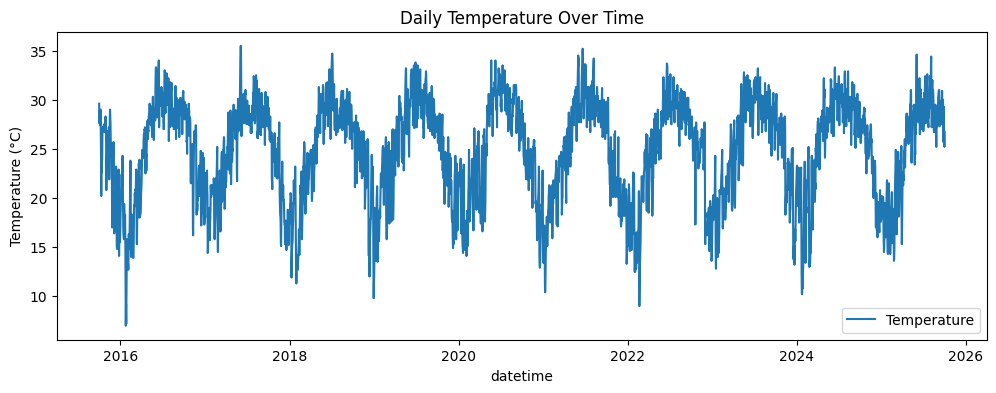

In [6]:
plt.figure(figsize=(12,4))
plt.plot(df["datetime"], df["temp"], label="Temperature")
plt.xlabel("datetime")
plt.ylabel("Temperature (°C)")
plt.title("Daily Temperature Over Time")
plt.legend()
plt.show()


Phát hiện dữ liệu ngoại lai(IQR)

In [7]:
Q1 = df["temp"].quantile(0.25)
Q3 = df["temp"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["temp"] < lower) | (df["temp"] > upper)]
print("Số điểm nghi ngờ ngoại lai:", len(outliers))


Số điểm nghi ngờ ngoại lai: 3


Phân chia dữ liệu theo chuỗi thời gian

In [8]:
df = df.sort_values("datetime").reset_index(drop=True)
split = int(len(df) * 0.8)
train = df.iloc[:split].copy()
test  = df.iloc[split:].copy()

Lưu kết quả phân chia dữ liệu 

In [9]:
train.to_csv('train.csv', index=False)
test.to_csv('test.csv', index=False)

In [10]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [11]:
print(f"train_shape: {train.shape}")
print(f"test_shape: {test.shape}")

train_shape: (2923, 33)
test_shape: (731, 33)


Chuyển đổi dữ liệu sang dạng Input/Output (X/y Split).

In [12]:
WINDOW_SIZE = 5

In [13]:
def data_to_input_and_output(data):

    input_data = []
    output_data = []
    for index in range(0, len(data) - WINDOW_SIZE):
        input_sample = data['temp'][index:index + WINDOW_SIZE]
        output_sample = data['temp'][index + WINDOW_SIZE]

        input_data.append(input_sample)
        output_data.append(output_sample)

    return np.array(input_data), np.array(output_data)

In [14]:
train_input, train_output = data_to_input_and_output(train)
test_input, test_output = data_to_input_and_output(test)

Huấn luyện mô hình


LSTM


In [15]:
def train_neural_network(X, y, epochs=100, learning_rate=0.005):

    model = Sequential()
    model.add(InputLayer((WINDOW_SIZE, 1)))
    model.add(LSTM(64))
    model.add(Dense(8, 'relu'))
    model.add(Dense(1, 'linear'))

    check_point = ModelCheckpoint('model.keras', save_best_only=True, monitor='loss')
    model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=learning_rate), metrics=[RootMeanSquaredError()])

    model.fit(X, y, epochs=epochs, callbacks=[check_point])
    return model

In [16]:
model = train_neural_network(train_input, train_output)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 172.3017 - root_mean_squared_error: 13.1264
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10.2279 - root_mean_squared_error: 3.1981
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.0326 - root_mean_squared_error: 1.7414
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.8445 - root_mean_squared_error: 1.6866
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7709 - root_mean_squared_error: 1.6646
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7612 - root_mean_squared_error: 1.6617
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7848 - root_mean_squared_error: 1.6688
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7543 - root_mean_squared_error: 1.6596
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7639 - root_mean_squared_error: 1.6625
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7609 - root_mean_squared_error: 1.

In [17]:
model = load_model('model.keras')

In [18]:
train_pred = model.predict(train_input)
test_pred = model.predict(test_input)

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Xây dựng hàm trực quan hóa kết quả


In [19]:
def plot_predictions(pred, y_true, label, period):
    period = pd.to_datetime(period)

    dfp = pd.DataFrame({
        "period": period,
        "y_true": np.ravel(y_true),
        "pred": np.ravel(pred),
    }).sort_values("period") 

    plt.figure(figsize=(10, 6))
    plt.plot(dfp["period"], dfp["y_true"], label="True Values", marker="o", color="black")
    plt.plot(dfp["period"], dfp["pred"],   label="Predictions", marker="o", color="red")
    plt.xlabel("Date")
    plt.ylabel("Mean temperature")
    plt.title(label)
    plt.legend()
    plt.gcf().autofmt_xdate()
    plt.show()


Trực quan hóa và so sánh kết quả


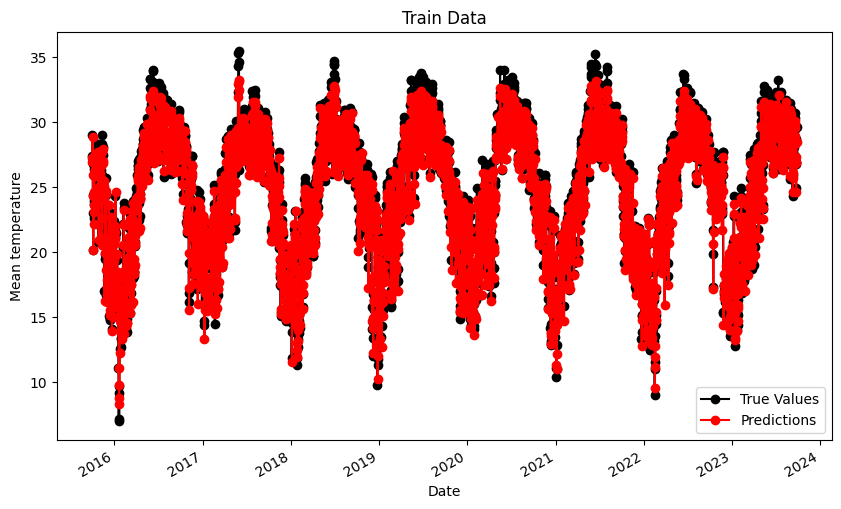

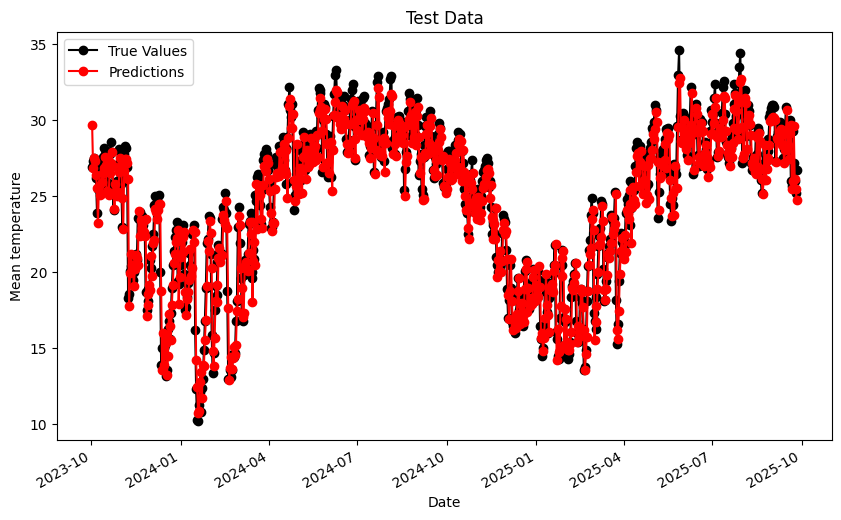

In [20]:
train_period = train[0:len(train) - WINDOW_SIZE]['datetime']
test_period = test[0:len(test) - WINDOW_SIZE]['datetime']

plot_predictions(train_pred, train_output, 'Train Data', train_period)
plot_predictions(test_pred, test_output, 'Test Data', test_period)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
rmse = np.sqrt(mean_squared_error(test_pred, test_output ))
mae  = mean_absolute_error(test_pred, test_output)
print("RMSE:", rmse)
print("MAE :", mae)


RMSE: 1.5854356651939232
MAE : 1.235079885908395


In [22]:
predictions = []

def predict_the_future(input_seq, period_prediction: int = 7):
    if period_prediction == 0:
        return None
    new_prediction = model.predict(input_seq)
    predictions.append(new_prediction[0][0])

    # input_seq = [[0], [1], [2], [3], [4]]
    # prediction = [5]
    # --> new_seq = [[1], [2], [3], [4], [5]]
    new_seq = np.array([np.concatenate((input_seq[0][1:WINDOW_SIZE], new_prediction[0]))])
    
    predict_the_future(new_seq, period_prediction - 1)

In [23]:
df.sort_values("datetime").tail(5)[["datetime", "temp"]]


,datetime,temp
3649,2025-09-27,29.3
3650,2025-09-28,27.2
3651,2025-09-29,26.0
3652,2025-09-30,25.2
3653,2025-10-01,26.7


In [24]:
predictions = []
seq_start = np.array([[29.3, 27.2, 26, 25.2, 26.7]])

if len(seq_start[0]) != WINDOW_SIZE:
    raise "Size mismatch"
predict_the_future(seq_start)

start_date = df["datetime"].iloc[-1] 

forecast_dates = pd.date_range(
    start=start_date + pd.Timedelta(days=1),
    periods=len(predictions),
    freq="D"
)

df_forecast = pd.DataFrame({
    "Date": forecast_dates.strftime("%d/%m/%Y"),
    "Predicted Temperature (°C)": [f"{p:.2f}" for p in predictions]
})

df_forecast

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,Date,Predicted Temperature (°C)
0,02/10/2025,26.60
1,03/10/2025,25.90
2,04/10/2025,25.06
3,05/10/2025,24.34
4,06/10/2025,23.91
5,07/10/2025,23.66
6,08/10/2025,23.44


Huấn luyện mô hình 


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Chuyển đổi dữ liệu về dạng 2 chiều (Samples, Features) cho các mô hình truyền thống
# Nếu train_input đang là (N, 5) thì giữ nguyên, nếu là (N, 5, 1) thì cần reshape
X_train_ml = train_input.reshape(train_input.shape[0], -1)
X_test_ml = test_input.reshape(test_input.shape[0], -1)

# Output giữ nguyên
y_train_ml = train_output
y_test_ml = test_output

print("Kích thước X_train cho ML:", X_train_ml.shape)
print("Kích thước X_test cho ML:", X_test_ml.shape)

Kích thước X_train cho ML: (2918, 5)
Kích thước X_test cho ML: (726, 5)


Linear Regression

In [26]:
# Khởi tạo và huấn luyện
lr_model = LinearRegression()
lr_model.fit(X_train_ml, y_train_ml)

# Dự báo
lr_pred = lr_model.predict(X_test_ml)

# Đánh giá
rmse = np.sqrt(mean_squared_error(y_test_ml, lr_pred))
print(f" RMSE: {rmse:.4f}")
print(f" MAE: {mae:.4f}")

 RMSE: 1.5849
 MAE: 1.2351


Random Forest


In [27]:
# Khởi tạo và huấn luyện (bạn có thể điều chỉnh n_estimators)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_ml, y_train_ml)

# Dự báo
rf_pred = rf_model.predict(X_test_ml)

# Đánh giá
rmse = np.sqrt(mean_squared_error(y_test_ml, rf_pred))
print(f" RMSE: {rmse:.4f}")
print(f" MAE: {mae:.4f}")

 RMSE: 1.7122
 MAE: 1.2351


Bảng tổng hợp chỉ số đánh giá của 3 mô hình

In [28]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- 1. Chuẩn bị dữ liệu ---
# Flatten dữ liệu cho các mô hình ML
X_train_ml = train_input.reshape(train_input.shape[0], -1)
y_train_ml = train_output
X_test_ml = test_input.reshape(test_input.shape[0], -1)
y_test_ml = test_output

# Hàm tính nhanh RMSE và MAE
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae

# --- 2. Mô hình Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_ml, y_train_ml)
# Dự báo trên cả Train và Test
lr_train_pred = lr_model.predict(X_train_ml)
lr_test_pred = lr_model.predict(X_test_ml)
# Tính lỗi
lr_train_rmse, lr_train_mae = calculate_metrics(y_train_ml, lr_train_pred)
lr_test_rmse, lr_test_mae = calculate_metrics(y_test_ml, lr_test_pred)

# --- 3. Mô hình Random Forest ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_ml, y_train_ml)
# Dự báo trên cả Train và Test
rf_train_pred = rf_model.predict(X_train_ml)
rf_test_pred = rf_model.predict(X_test_ml)
# Tính lỗi
rf_train_rmse, rf_train_mae = calculate_metrics(y_train_ml, rf_train_pred)
rf_test_rmse, rf_test_mae = calculate_metrics(y_test_ml, rf_test_pred)

# --- 4. Mô hình LSTM (đã chạy từ trước) ---
# train_pred và test_pred thường đã được tính ở phần LSTM code trước đó
# Nếu chưa có biến train_pred, bạn cần chạy: train_pred = model.predict(train_input)
lstm_train_rmse, lstm_train_mae = calculate_metrics(train_output, train_pred)
lstm_test_rmse, lstm_test_mae = calculate_metrics(test_output, test_pred)

# --- 5. Tạo bảng tổng hợp toàn diện ---
metrics_data = {
    'Model': ['Linear Regression', 'Random Forest', 'LSTM'],
    'Train RMSE': [lr_train_rmse, rf_train_rmse, lstm_train_rmse],
    'Test RMSE': [lr_test_rmse, rf_test_rmse, lstm_test_rmse],
    'Train MAE': [lr_train_mae, rf_train_mae, lstm_train_mae],
    'Test MAE': [lr_test_mae, rf_test_mae, lstm_test_mae]
}

df_metrics = pd.DataFrame(metrics_data)

# Sắp xếp theo Test RMSE để tìm mô hình tốt nhất cho thực tế
df_metrics = df_metrics.sort_values(by='Test RMSE').reset_index(drop=True)

print("=== BẢNG SO SÁNH HIỆU QUẢ MÔ HÌNH (TRAIN vs TEST) ===")
display(df_metrics)

=== BẢNG SO SÁNH HIỆU QUẢ MÔ HÌNH (TRAIN vs TEST) ===


,Model,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Linear Regression,1.608818,1.584923,1.182967,1.189057
1,LSTM,1.604430,1.585436,1.237434,1.235080
2,Random Forest,0.637561,1.712204,0.473531,1.309302
